# Scenario — how it works

This is the explanation and reference for the `quicksat` scenario. It covers what the scenario file holds, how a run turns it into a timeline, and where the model stops.

It is not a tutorial. The worked example is `sample/scenario/scenario.ipynb`. This notebook still runs, so that it cannot drift from the code. It reads `docs/scenario/data/`, its own copy of the inputs. The figures quoted below are true of that data.

A scenario is an orbit and a list of activities. Each activity sets an attitude and a mode until its trigger ends it. Sizing, the scenario and power are separate domains (`docs/explanations/decisions.md`, entry 10). Power will check a sizing against one or more scenarios, and builds on the run described here.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from astropy.coordinates import GCRS, CartesianRepresentation, SkyCoord
from astropy.time import Time
from sgp4.api import WGS72, Satrec

# Make the in-development quicksat package importable without installing it: walk up
# from the current directory to the repo root (the folder that holds the quicksat
# package) and switch to it. Works whether the notebook runs from docs/, the repo
# root, or the docs build.
here = Path.cwd()
repo_root = next(
    (p for p in (here, *here.parents) if (p / "quicksat" / "__init__.py").exists()),
    None,
)
if repo_root is None:
    raise RuntimeError("could not locate the quicksat repo root")
os.chdir(repo_root)

from quicksat import Q_, u
from quicksat.orbit.ecsv_trajectory import write_ecsv_trajectory
from quicksat.orbit.geometry import light_fraction, shadow_cones, sun_positions
from quicksat.orbit.oem_trajectory import write_oem_trajectory
from quicksat.orbit.omm import read_omm_file, write_omm_file
from quicksat.orbit.sso import MEAN_SUN_RATE, sso_tle
from quicksat.orbit.tle import Tle, read_tle_file
from quicksat.orbit.trajectory import Trajectory
from quicksat.scenario.attitude import body_rotations
from quicksat.scenario.config import Scenario, parse_trigger
from quicksat.scenario.plots import gantt_chart
from quicksat.scenario.run import run_scenario
from quicksat.scenario.spacecraft import read_glb_json
from quicksat.scenario.viewer import scenario_data
from quicksat.utils.intervals import TimeArray, labels_at
from quicksat.utils.plot_helpers import STYLE

plt.style.use(STYLE)

DATA = Path("docs") / "scenario" / "data"
SCENARIO_FILE = DATA / "scenario.yaml"
BASE = yaml.safe_load(SCENARIO_FILE.read_text())


def run_variant(activities, **changes):
    """
    Run the reference scenario with other activities, and any other keys changed.

    The variants leave out the 3D model: its wings park in imaging, and a variant
    may have no imaging, which the check on load refuses.
    """
    data = {key: value for key, value in BASE.items() if key != "3d_model"}
    data |= changes | {"activities": activities}
    return run_scenario(Scenario.from_yaml_text(yaml.safe_dump(data), base_dir=DATA))


def show_table(run):
    """The activity table, with its summary line above it."""
    print(run.activity_summary)
    return run.activity_table.style.hide(axis="index").format(
        {"duration [min]": "{:.2f}", "outside [s]": "{:.1f}"}, na_rep=""
    )

## The scenario file

The scenario is one YAML file, written by hand. No notebook writes it.

| Key | What it holds |
| --- | --- |
| `orbit` | Where the orbit comes from: a TLE file, an OMM file, a sun-synchronous orbit, or a trajectory file in ECSV or CCSDS OEM. Exactly one. |
| `start` | The start of the run, in UTC |
| `duration` | The length of the run: a time, such as `5 h`, or a number of orbits, such as `3 orbits` |
| `step` | The time step of the grid, 10 s by default |
| `attitudes` | The body axes of the `nadir` and `sun pointing` attitudes |
| `activities` | One repeat of the list of activities |
| `slew` | How the body turns between attitudes. Optional: without it, attitude changes are instant. |
| `3d_model` | The spacecraft's 3D model, a GLB file, for the viewer, and the parts of it that turn to face the sun. Optional: without it, the viewer draws a 1 m cube. |

This notebook's file:

In [2]:
print(SCENARIO_FILE.read_text())

# The scenario of the scenario reference notebook, docs/scenario/scenario_ref.ipynb.
#
# The notebook quotes figures from this run, so this file changes only with it.
# The worked example has its own copy, in sample/scenario/data/.

orbit:
  # A 510 km sun-synchronous orbit at 10:30 LTAN, with its epoch at the start
  tle_file: sso_510km.tle

start: 2026-10-01T00:00:00
duration: 3 orbits
step: 10 s

# The spacecraft's 3D model, which the viewer draws, in body axes and metres, and
# the wings that turn to face the sun, parked in imaging
3d_model:
  file: spacecraft.glb
  articulations:
    wing +y: {part: Wing +y, axis: +y, sun_axis: -z, park: {imaging: 0 deg}}
    wing -y: {part: Wing -y, axis: +y, sun_axis: -z, park: {imaging: 0 deg}}

attitudes:
  nadir: {nadir_axis: +z, orbit_normal: -y}
  sun pointing: {sun_axis: -z, constrain_to_orbit_normal: -y}

activities:
  - [eclipse entry, sun pointing, idle, sunlit]
  - [eclipse exit, nadir, idle, eclipse]
  - [latitude 45 deg - 2 min, sun 

## The orbit

There are multiple ways to define an orbit.

### A TLE file

`tle_file` names a file that holds exactly one TLE, in two lines, or three with a name first. A relative path is taken from the folder of the scenario file. sgp4 checks the checksums and the columns as it reads the lines.

The orbit is propagated with SGP4 and moved from TEME to GCRS by astropy. A run that starts more than 7 days from the TLE epoch gets a warning, because SGP4 loses accuracy away from its epoch.

### A sun-synchronous orbit

`sso: {altitude: 510 km, ltan: "10:30"}` asks quicksat to build the TLE. Its epoch is the start of the run. A TLE holds SGP4's own mean elements, so each element is set against SGP4 itself:

- **The inclination** makes SGP4's node rate match the mean sun: 360° in 365.2422 days. SGP4 works that rate out from J2, J2 squared and J4.
- **The mean motion** makes the altitude, averaged over one orbit, match the one asked for. The altitude is the distance from the centre of the Earth minus `R_EARTH`.
- **The right ascension of the node** puts the node at the asked local mean time at the epoch.

The cell below builds that orbit, and compares it with the TLE file. The file holds the same orbit, but with its inclination from a formula with J2 alone. That inclination is 0.007° lower. Under SGP4, it turns the node away from the sun by 1.34 min of local time a year.

In [3]:
built = sso_tle(Time("2026-10-01T00:00:00", scale="utc"), Q_(510, "km"), Q_(10.5, "h"))
filed = read_tle_file(DATA / "sso_510km.tle")

for name, tle in (("built from sso", built), ("the TLE file", filed)):
    satrec = tle.satrec
    # the node's turn against the mean sun, in degrees a year
    turn = (
        Q_(satrec.nodedot, "rad / min").to(u.deg / u.yr).value
        - MEAN_SUN_RATE.to(u.deg / u.yr).value
    )
    # 15 degrees of node turn is an hour of local time
    drift = Q_(turn / 15 * 60, "min / yr")
    print(
        f"{name:15} inclination {np.degrees(satrec.inclo):.4f} deg, "
        f"nodal period {tle.nodal_period.to(u.min):.4f}, node drift {drift:+.2f}"
    )

print()
print("The built TLE, written out:")
print("\n".join(built.lines))

built from sso  inclination 97.4465 deg, nodal period 94.8509 min, node drift +0.00 min / yr
the TLE file    inclination 97.4398 deg, nodal period 94.8525 min, node drift -1.34 min / yr

The built TLE, written out:
1 99999U          26274.00000000  .00000000  00000-0  00000+0 0    08
2 99999  97.4465 167.2426 0000000   0.0000   0.0000 15.19140911    02


Written out as TLE lines, the angles round to 0.0001°. quicksat keeps the built element set at full precision, so the rounding never enters a run.

Write the LTAN in quotes, `"10:30"`, or as a time, `10.5 h`. YAML reads an unquoted `10:30` as a base-60 number, 630. So a bare number is rejected, and the message says why:

In [4]:
for ltan in ['"10:30"', "10.5 h", "10:30"]:
    orbit = yaml.safe_load(f"sso: {{altitude: 510 km, ltan: {ltan}}}")
    try:
        Scenario.from_yaml_text(yaml.safe_dump(BASE | {"orbit": orbit}), base_dir=DATA)
        print(f"ltan: {ltan:9} accepted")
    except ValueError as error:
        reason = str(error).split("Value error, ")[-1].split(" [type=")[0]
        print(f"ltan: {ltan:9} rejected: {reason}")

ltan: "10:30"   accepted
ltan: 10.5 h    accepted
ltan: 10:30     rejected: ltan must be a time of day, such as "10:30" in quotes, or 10.5 h. Got the bare number 630. YAML reads an unquoted 10:30 as the number 630, so put it in quotes.


### An OMM file

`omm_file` names a CCSDS Orbit Mean-Elements Message. It holds the same elements as a TLE, as named fields such as `MEAN_MOTION` and `BSTAR`, at full precision. quicksat reads it in each of the forms in use, and tells them apart by their first character:

- **KVN,** the CCSDS text form, starts with `CCSDS_OMM_VERS`. Units in brackets, such as `[rev/day]`, are not read.
- **XML,** the CCSDS XML form, starts with `<`.
- **JSON,** as CelesTrak and Space-Track give it, starts with `[` or `{`.
- **CSV,** as CelesTrak gives it, starts with a header line of field names.

The file holds exactly one element set. Where the file gives them, the centre must be the Earth, the frame TEME, the time system UTC, and the element theory SGP4. Other elements would not mean the same thing to SGP4. `BSTAR` is required, since without it the drag would be lost. The bookkeeping fields, such as `ELEMENT_SET_NO`, take a TLE's usual values where the file leaves them out.

sgp4 builds the same `Satrec` from an OMM as from a TLE, so an OMM runs exactly as the TLE of the same elements does. `write_omm_file` writes an element set as an OMM in KVN, such as the one quicksat builds for a sun-synchronous orbit. The cell below writes this notebook's TLE as an OMM, and reads it back:

In [5]:
OMM_FILE = DATA / "sso_510km.omm"
write_omm_file(OMM_FILE, filed, creation_date=filed.epoch)
print(OMM_FILE.read_text())

from_omm = read_omm_file(OMM_FILE)
print(f"the same TLE lines as the file   {from_omm.lines == filed.lines}")

CCSDS_OMM_VERS = 2.0
CREATION_DATE = 2026-10-01T00:00:00
ORIGINATOR = quicksat

OBJECT_NAME = UNKNOWN
OBJECT_ID = UNKNOWN
CENTER_NAME = EARTH
REF_FRAME = TEME
TIME_SYSTEM = UTC
MEAN_ELEMENT_THEORY = SGP4

EPOCH = 2026-10-01T00:00:00.000000
MEAN_MOTION = 15.19115961 [rev/day]
ECCENTRICITY = 0.0
INCLINATION = 97.4398 [deg]
RA_OF_ASC_NODE = 167.2426 [deg]
ARG_OF_PERICENTER = 0.0 [deg]
MEAN_ANOMALY = 0.0 [deg]

EPHEMERIS_TYPE = 0
CLASSIFICATION_TYPE = U
NORAD_CAT_ID = 99999
ELEMENT_SET_NO = 0
REV_AT_EPOCH = 0
BSTAR = 0.0 [1/ER]
MEAN_MOTION_DOT = 0.0 [rev/day**2]
MEAN_MOTION_DDOT = 0.0 [rev/day**3]

the same TLE lines as the file   True


### A trajectory file

`trajectory_file` names an ECSV file, or a CCSDS OEM as below. ECSV is astropy's CSV, with a YAML header that gives each column's unit and says what the numbers mean. The columns are `time`, the position `x`, `y` and `z`, and the velocity `vx`, `vy` and `vz`. Any unit of time, length and speed will do.

- **The time** counts from `epoch` in the header, in its `time_scale`. Both are required, since UTC and TT differ by 69 s.
- **The frame** is GCRS, ITRS, TEME, CIRS, TETE or EME2000. ICRS and FK5 are refused: astropy centres them on the solar system's barycentre, so a satellite's position would land 150 million km away. The states go into GCRS once, as the file is read.
- **Between the samples,** one spline of degree 5 runs through the positions and another through the velocities, as in satmad. So the run keeps the file's own velocities.
- **Nothing is extrapolated.** The run must lie inside the file. Within three samples of either end, the spline has less to go on, so a run that comes that close gets a warning. Let the file reach a few samples past the run.
- **One orbit is measured from the file,** as the mean time between ascending nodes. That is SGP4's nodal period, measured instead of predicted. A file shorter than one orbit cannot take a duration in orbits.
- **A manoeuvre** breaks the velocity, and one spline across it smooths it over. ECSV has no segments to split it. An OEM has: see below.

Against SGP4 on this orbit, the position error is:

| Spacing of the samples | Inside the file | At its ends |
| --- | --- | --- |
| 60 s | 0.3 mm | 9 mm |
| 120 s | 2 cm | 0.57 m |
| 300 s | 5 m | 131 m |

So 60 s, or 120 s at most, suits a low orbit. `write_ecsv_trajectory` writes the format. The cell below writes this notebook's trajectory file from its TLE, at 60 s in ITRS, from 10 min before the run to 10 min after it:

In [6]:
TRAJECTORY_FILE = DATA / "sso_510km_itrs.ecsv"
offsets = np.arange(-600.0, 3 * filed.nodal_period.to(u.s).value + 660.0, 60.0)
write_ecsv_trajectory(
    TRAJECTORY_FILE, filed.states(filed.epoch + offsets * u.s), frame="ITRS", name="SSO 510 km"
)
lines = TRAJECTORY_FILE.read_text().splitlines()
print("\n".join(lines[:18]))
print(f"... and {len(lines) - 18} more rows")

# %ECSV 1.0
# ---
# datatype:
# - {name: time, unit: s, datatype: float64}
# - {name: x, unit: km, datatype: float64}
# - {name: y, unit: km, datatype: float64}
# - {name: z, unit: km, datatype: float64}
# - {name: vx, unit: km / s, datatype: float64}
# - {name: vy, unit: km / s, datatype: float64}
# - {name: vz, unit: km / s, datatype: float64}
# meta: !!omap
# - {epoch: '2026-09-30T23:50:00.000'}
# - {time_scale: utc}
# - {frame: ITRS}
# - {object_name: SSO 510 km}
# schema: astropy-2.0
time x y z vx vy vz
0.0 -5288.590862 1338.957773 -4213.430985 -4.037821473 2.715138727 5.936042533
... and 305 more rows


The reference scenario, run from this file and from the TLE, gives the same timeline:

In [7]:
from_tle = run_scenario(Scenario.from_yaml_file(SCENARIO_FILE))
from_file = run_variant(BASE["activities"], orbit={"trajectory_file": TRAJECTORY_FILE.name})


def eclipse_edges(run) -> np.ndarray:
    """Each eclipse's entry and exit, in seconds from the start."""
    return np.array(
        [[(piece.lower - run.times[0]).to_value(u.s), (piece.upper - run.times[0]).to_value(u.s)] for piece in run.eclipses]
    )


same = [o.statuses for o in from_file.occurrences] == [o.statuses for o in from_tle.occurrences]
gap = np.abs(eclipse_edges(from_file) - eclipse_edges(from_tle)).max()
print(f"one orbit, SGP4's nodal period   {from_tle.orbit.period.to(u.s):.4f}")
print(f"one orbit, measured from file    {from_file.orbit.period.to(u.s):.4f}")
print(f"eclipse edges, largest gap       {gap * 1000:.1f} ms")
print(f"the same statuses                {same}")

one orbit, SGP4's nodal period   5691.1487 s
one orbit, measured from file    5691.1480 s
eclipse edges, largest gap       0.0 ms
the same statuses                True


**Below 1° of inclination, the node is not well defined.** A geostationary orbit has none at all. There, one orbit is the mean time between crossings of a half-plane fixed in GCRS. The half-plane holds the orbit normal and the GCRS axis that lies most in the orbit plane. The sun would not do as the reference: it moves a degree a day, so it would give the solar day, 4 min longer than the orbit. This is for trajectory files only. A TLE keeps SGP4's nodal period.

The cell below samples satmad's geostationary element set, with an inclination of exactly 0°, every 60 s for three days:

In [8]:
geo_tle = Tle(
    "GEO",
    Satrec.twoline2rv(
        "1 99999U 12345A   20162.50918981  .00000000  00000-0  00000-0 0 00005",
        "2 99999 000.0000 124.6202 0000000 000.0000 000.0000 01.00273791000004",
        WGS72,
    ),
)
geo_samples = geo_tle.epoch + np.arange(0, 3 * 86400.0 + 60.0, 60.0) * u.s
geo_trajectory = Trajectory.from_states(geo_tle.states(geo_samples))
print(f"one orbit       {geo_trajectory.period.to(u.s):.2f}, from {geo_trajectory.period_method}")
print(f"sidereal day    {(1 * u.sday).to(u.s):.2f}")

one orbit       86162.06 s, from a fixed direction
sidereal day    86164.09 s


### A CCSDS OEM

`trajectory_file` may name a CCSDS Orbit Ephemeris Message instead, in KVN, its plain-text form. quicksat tells the two formats apart by the first line: `# %ECSV` or `CCSDS_OEM_VERS`. An XML OEM is refused.

An OEM holds a header, then segments. Each segment has its metadata between `META_START` and `META_STOP`, then its data lines: an epoch, the position in km and the velocity in km/s. Versions 1.0, 2.0 and 3.0 are read.

- **The centre** must be `EARTH`. OEM gives the origin apart from the axes, so `ICRF` centred on the Earth means the GCRS axes.
- **The frames** are read as:

  | `REF_FRAME` | Read as |
  | --- | --- |
  | `EME2000` | EME2000, astropy's `PrecessedGeocentric` at J2000 |
  | `GCRF`, `ICRF` | GCRS |
  | `ITRF` and its realisations, such as `ITRF2000` | ITRS |
  | `TEME` | TEME |
  | `TOD` | TETE |
  | `CIRF` | CIRS |

  `GRC` and `TDR` turn with the Earth but leave out polar motion, about 10 m in low orbit, and astropy has no such frame. They are refused. Where 10 m will do, change the frame in the file to `ITRF` by hand. A `REF_FRAME_EPOCH` is refused too.
- **The time systems** are UTC, TAI, TT, TDB, TCB, TCG, UT1, and GPS, which is TAI less 19 s. An epoch is a date, or a day of the year such as `2026-274T00:00:00`.
- **Each segment gets its own splines.** A new segment usually follows a manoeuvre, so the change of velocity is kept, not smoothed over. Where two segments meet, the later one applies from that epoch. A run may not cross a gap between two segments.
- **The useable span,** where a segment gives `USEABLE_START_TIME` and `USEABLE_STOP_TIME`, is what the segment serves. The samples beyond it still feed its splines.
- **A segment of under six samples** gets splines of a lower degree, and a warning. So does a short ECSV file.
- **Not read:** the covariance, the accelerations, and the interpolation the file suggests. quicksat uses its own splines.

`write_oem_trajectory` writes one segment. The cell below writes this notebook's orbit as an OEM in EME2000, and runs the reference scenario from it:

In [9]:
OEM_FILE = DATA / "sso_510km_eme2000.oem"
write_oem_trajectory(
    OEM_FILE,
    filed.states(filed.epoch + offsets * u.s),
    name="SSO 510 km",
    creation_date=filed.epoch,
)
print("\n".join(OEM_FILE.read_text().splitlines()[:16]))

from_oem = run_variant(BASE["activities"], orbit={"trajectory_file": OEM_FILE.name})
oem_orbit = from_oem.orbit
assert isinstance(oem_orbit, Trajectory)
same = [o.statuses for o in from_oem.occurrences] == [o.statuses for o in from_tle.occurrences]
gap = np.abs(eclipse_edges(from_oem) - eclipse_edges(from_tle)).max()
print()
print(f"read as              {oem_orbit.format} in {oem_orbit.frame}, {oem_orbit.segment_count} segment")
print(f"one orbit            {oem_orbit.period.to(u.s):.4f}")
print(f"eclipse edges, gap   {gap * 1000:.1f} ms")
print(f"the same statuses    {same}")

CCSDS_OEM_VERS = 2.0
CREATION_DATE = 2026-10-01T00:00:00
ORIGINATOR = quicksat

META_START
OBJECT_NAME = SSO 510 km
OBJECT_ID = UNKNOWN
CENTER_NAME = EARTH
REF_FRAME = EME2000
TIME_SYSTEM = UTC
START_TIME = 2026-09-30T23:50:00.000000
STOP_TIME = 2026-10-01T04:55:00.000000
META_STOP

2026-09-30T23:50:00.000000 -5422.054977 694.433185 -4199.295688 -4.369609683 1.816535566 5.947423582
2026-09-30T23:51:00.000000 -5672.179447 801.826904 -3833.498764 -3.964791917 1.761938725 6.241350483



read as              OEM in EME2000, 1 segment
one orbit            5691.1480 s
eclipse edges, gap   0.0 ms
the same statuses    True


## The period of the run

**The start** is a UTC time. YAML turns an unquoted ISO time into a datetime, and that is accepted too.

**The duration** is a time, such as `5 h`, or a number of orbits, such as `3 orbits`. A count need not be whole, and `1 orbit` works too. One orbit is the nodal period of the element set: the time from one ascending node to the next, at SGP4's secular rates. The period from the position and velocity at one moment is no good here. J2 makes it wander from 19 s below the nodal period to 4 s above.

**The step** sets the time grid. The orbit is evaluated at each step, and the events are then located between the steps. The step also sets the grid of the plots and of the viewer. The last step is shorter when the step does not divide the duration, so that the grid ends exactly at the end of the run.

After three orbits, the satellite is back at the latitude it started at:

In [10]:
run = run_scenario(Scenario.from_yaml_file(SCENARIO_FILE))

last_step = (run.times[-1] - run.times[-2]).to(u.s)
print(f"nodal period       {run.orbit.period.to(u.min):.4f}")
print(f"3 orbits           {(run.times[-1] - run.times[0]).to(u.min):.4f}")
print(f"grid               {len(run.times)} times, the last step {last_step:.3f}")
print(f"latitude at start  {run.latitude[0]:.3f}")
print(f"latitude at end    {run.latitude[-1]:.3f}")

nodal period       94.8525 min
3 orbits           284.5574 min
grid               1709 times, the last step 3.446 s
latitude at start  -0.123 deg
latitude at end    -0.123 deg


## The attitudes

There are two attitudes, with fixed names for now. The file sets their body axes. An axis is written with its sign, such as `+z` or `-y`. The two axes of an attitude must be different body axes.

- **`nadir`** points `nadir_axis` at the centre of the Earth. It puts `orbit_normal` along the orbit normal, which is the position crossed with the velocity. With `+z` and `-y`, the body axes match LVLH: x along the track, y minus the orbit normal and z nadir.
- **`sun pointing`** points `sun_axis` at the sun, as seen from the satellite. A second axis comes as close as it can to one of two directions, and the file gives exactly one:
  - `constrain_to_orbit_normal` keeps the second axis along the orbit normal. The body then stays still over an orbit, and the Earth turns around it.
  - `constrain_to_nadir` keeps the second axis facing the Earth, which suits an antenna. But the body spins about the sun axis when the sun comes close to the nadir line.

The cell below flies one orbit in sun pointing, at 12:00 LTAN, where beta is small. It measures the fastest turn of the body between two steps, with each constraint.

In [11]:
def peak_rate(run):
    """The fastest turn of the body between two steps of the grid."""
    rotations = body_rotations(run)
    relative = np.einsum("nji,njk->nik", rotations[:-1], rotations[1:])
    cosine = (np.trace(relative, axis1=1, axis2=2) - 1) / 2
    angle = np.degrees(np.arccos(np.clip(cosine, -1, 1)))
    steps = np.diff((run.times - run.times[0]).to_value(u.s))
    return Q_(np.max(angle / steps), "deg / s")


noon = {"sso": {"altitude": "510 km", "ltan": "12:00"}}
for constraint in ({"constrain_to_orbit_normal": "-y"}, {"constrain_to_nadir": "+y"}):
    flown = run_variant(
        [["1 day", "sun pointing", "idle"]],
        orbit=noon,
        duration="1 orbit",
        attitudes={"sun pointing": {"sun_axis": "-z", **constraint}},
    )
    name = next(iter(constraint))
    print(f"beta {flown.beta.mean():.1f}, {name:26} peak rate {peak_rate(flown):.3f}")

beta 2.9 deg, constrain_to_orbit_normal  peak rate 0.000 deg / s


beta 2.9 deg, constrain_to_nadir         peak rate 1.223 deg / s


The orbit itself turns at 0.063°/s. Measured for a circular orbit, the peak spin about the sun axis grows quickly as beta falls:

| Beta | `constrain_to_nadir` | `constrain_to_orbit_normal` |
| --- | --- | --- |
| 20° | 0.19°/s | 0 |
| 8° | 0.45°/s | 0 |
| 2° | 1.8°/s | 0 |
| 0.5° | 7.3°/s | 0 |

The orbit normal gives no spin, because it and the sun each move by only about a degree a day. Nothing warns about the spin with `constrain_to_nadir`. It is the user's choice.

Sun pointing is undefined where the sun lies along its second direction. That is along the orbit normal at a beta of ±90°, or along the nadir line, deep in an eclipse. At such a time, the other of the two directions takes its place.

Without a `slew` block, attitude changes are instant: at each step of the grid, the body takes the attitude of the activity under way then. The next section adds slews.

### Slews

Without a `slew` block, attitude changes are instant. With one, the body turns into each new attitude before the activity that needs it starts:

```yaml
slew:
  max_rate: 0.7 deg/s
  max_acceleration: 0.08 deg/s2
  settling_time: 20 s
```

- **The turn** goes from rest to rest about one axis. It speeds up at the maximum acceleration, coasts at the maximum rate if it reaches it, and slows down again. A short turn never reaches the maximum rate: it speeds up to its midpoint and slows down from there. Either limit can be left out, but not both.
- **The settling time** follows the turn, 0 s by default.
- **The slew takes the end of the activity before**, so each activity starts in its own attitude. The turn starts from the orientation the body has then. Its time follows from the angle to the new attitude, as that attitude will be when the turn ends.
- **If the activity before is shorter than the slew**, the slew starts earlier still, and the activity it leads into gets the status `slew starts early`.

This is the agility budget's profile, with one rate and one acceleration for every axis. The values above are close to the sizing sample's, but nothing reads them from the agility budget. With them, a 90° turn takes 90 / 0.7 + 0.7 / 0.08 = 137.3 s, and a turn under 6.1° never reaches the maximum rate.

The targets move too: nadir turns with the orbit at 0.063°/s. So during a slew, the body can turn up to that much faster than the maximum rate.

The reference run, with this block added:

In [12]:
SLEW = {"max_rate": "0.7 deg/s", "max_acceleration": "0.08 deg/s2", "settling_time": "20 s"}
slewing = run_variant(BASE["activities"], slew=SLEW)

for window in slewing.slews[:4]:
    occurrence = slewing.occurrences[window.into]
    turn = (window.turned - window.start).to(u.s)
    print(
        f"into activity {occurrence.number} of repeat {occurrence.repeat}, "
        f"{window.target:12} {window.angle:6.1f}, turn {turn:6.1f}, "
        f"{window.duration} with settling"
    )

into activity 2 of repeat 1, nadir         113.4 deg, turn  170.8 s, 190.806 s with settling
into activity 3 of repeat 1, sun pointing  128.1 deg, turn  191.7 s, 211.678 s with settling
into activity 4 of repeat 1, nadir          46.4 deg, turn   75.1 s, 95.078 s with settling
into activity 1 of repeat 2, sun pointing   95.6 deg, turn  145.3 s, 165.268 s with settling


In repeats 2 and 3, the first activity lasts only 2.3 min, from the end of the downlink to the eclipse entry. The slew out of it into nadir takes 3.2 min, so it starts during the downlink, and the table flags it. The `slew [s]` column gives each activity's slew. In the Gantt chart, the slews show in grey in the attitude row.

In the viewer's data, each slew is a piece of the attitude track of its own, with the value `slew` and the attitude it turns into as `target`. The viewer names it that way, such as `nadir (slewing)`. Its colour is the grey of `slew`. The body's orientation through the slew is in `q_body`, so the 3D view shows the turn.

In [13]:
show_table(slewing)

Occurrences: 13 in 3 repeats. Negative duration: 0. Outside constraint: 0. Event never came: 0. Cut at end: 1. Slew starts early: 2.


repeat,activity,start [UTC],end [UTC],duration [min],trigger,attitude,slew [s],mode,constraint,outside [s],status
1,1,2026-10-01T00:00:00.000,2026-10-01T00:28:21.369,28.36,eclipse entry,sun pointing,,idle,sunlit,0.0,ok
1,2,2026-10-01T00:28:21.369,2026-10-01T01:03:15.398,34.90,eclipse exit,nadir,190.806000,idle,eclipse,0.0,ok
1,3,2026-10-01T01:03:15.398,2026-10-01T01:44:48.679,41.55,latitude 45 deg - 2 min,sun pointing,211.678000,idle,sunlit,0.0,ok
1,4,2026-10-01T01:44:48.679,2026-10-01T01:50:48.679,6.00,latitude 45 deg + 4 min,nadir,95.078000,imaging,sunlit,0.0,ok
1,5,2026-10-01T01:50:48.679,2026-10-01T02:00:48.679,10.00,10 min,nadir,,downlink,,,ok
2,1,2026-10-01T02:00:48.679,2026-10-01T02:03:12.086,2.39,eclipse entry,sun pointing,165.268000,idle,sunlit,0.0,ok
2,2,2026-10-01T02:03:12.086,2026-10-01T02:38:06.161,34.90,eclipse exit,nadir,179.299000,idle,eclipse,0.0,slew starts early
2,3,2026-10-01T02:38:06.161,2026-10-01T03:19:39.828,41.56,latitude 45 deg - 2 min,sun pointing,211.674000,idle,sunlit,0.0,ok
2,4,2026-10-01T03:19:39.828,2026-10-01T03:25:39.828,6.00,latitude 45 deg + 4 min,nadir,95.106000,imaging,sunlit,0.0,ok
2,5,2026-10-01T03:25:39.828,2026-10-01T03:35:39.828,10.00,10 min,nadir,,downlink,,,ok


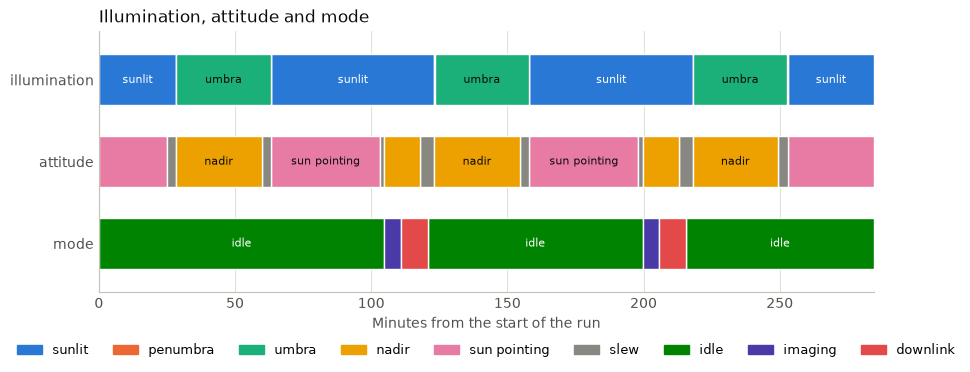

In [14]:
gantt_chart(slewing)
plt.show()

## The activities

Each activity is a list of three or four fields:

1. **The trigger** that ends it.
2. **The attitude**, `nadir` or `sun pointing`. The attitude sets the geometry, so it drives the power generated.
3. **The mode**. Any name works. The mode sets what the equipment draws, so it drives the power consumed.
4. **The constraint**, optional: the illumination the activity expects. It is `sunlit`, `penumbra`, `umbra`, or `eclipse` for either of the last two.

The activities form a chain. The first starts at the start of the run, and each later one starts where the one before it ends. The file holds one repeat of the list, and the run repeats it until the duration ends. An activity that would run past the end is cut there.

### The triggers

| Trigger | Ends the activity at |
| --- | --- |
| `20 min` | 20 min after it starts |
| `eclipse entry`, `umbra entry`, `umbra exit`, `eclipse exit` | the next shadow edge: into the penumbra, into the umbra, out of the umbra, and out of the penumbra |
| `ascending node`, `descending node` | the next crossing of the equator, northward or southward |
| `latitude 30 deg ascending` | the next crossing of 30° going north |
| `latitude -30 deg descending` | the next crossing of −30° going south |
| `latitude 45 deg` | the next crossing of 45°, in either direction |
| an event `+` or `-` an offset | such as `eclipse entry + 2 min` or `descending node - 30 s` |

Every trigger looks forward from the activity's start. An event trigger ends the activity at the next such event strictly after it starts. So an activity that starts at an eclipse entry and ends at `eclipse entry` lasts a whole orbit.

An offset is applied after the event is found. So `latitude 45 deg - 2 min` finds the next crossing of 45°, then ends the activity 2 min before it. The latitude is geodetic, as on a map. The words may be in any case.

Event triggers keep a repeated list in step with the orbit. Fixed durations drift against it. A list of whole minutes adding up to 95 min drifts 8.9 s an orbit against the 94.85 min nodal period, which is 2.2 min a day.

The parser accepts the forms in the table, and says what is wrong with anything else:

In [15]:
for text in [
    "20 min",
    "eclipse entry + 2 min",
    "descending node - 30 s",
    "latitude 45 deg",
    "latitude -30 deg descending",
    "latitude 30",
    "latitude 95 deg",
    "eclipse entry + 2",
    "20 min + 2 min",
]:
    try:
        trigger = parse_trigger(text)
    except ValueError as error:
        print(f"{text:28} rejected: {str(error).split('. ')[0]}")
        continue
    if trigger.duration is not None:
        meaning = f"a duration of {trigger.duration}"
    else:
        meaning = f"{trigger.event}"
        if trigger.latitude is not None:
            meaning += f" of {trigger.latitude}, {trigger.direction or 'either direction'}"
        if trigger.offset is not None:
            meaning += f", offset {trigger.offset}"
    print(f"{text:28} accepted: {meaning}")

20 min                       accepted: a duration of 20.0 min
eclipse entry + 2 min        accepted: eclipse entry, offset 2.0 min
descending node - 30 s       accepted: latitude crossing of 0.0 deg, descending, offset -30.0 s
latitude 45 deg              accepted: latitude crossing of 45.0 deg, either direction
latitude -30 deg descending  accepted: latitude crossing of -30.0 deg, descending
latitude 30                  rejected: trigger 'latitude 30' is not understood
latitude 95 deg              rejected: trigger 'latitude 95 deg' needs a latitude from -90 to 90 deg, got 95.0 deg
eclipse entry + 2            rejected: trigger 'eclipse entry + 2' has an offset that is not a time with a unit
20 min + 2 min               rejected: trigger '20 min + 2 min' is not understood


### The reference run

The file above runs three orbits. The list sun-points until the eclipse, and points nadir through it. After the eclipse, activities 3 and 4 end at crossings of 45°. The imaging runs from 2 min before the next crossing to 4 min after it, so it always lasts 6 min. The last activity is cut by the end of the run.

In [16]:
show_table(run)

Occurrences: 13 in 3 repeats. Negative duration: 0. Outside constraint: 0. Event never came: 0. Cut at end: 1. Slew starts early: 0.


repeat,activity,start [UTC],end [UTC],duration [min],trigger,attitude,slew [s],mode,constraint,outside [s],status
1,1,2026-10-01T00:00:00.000,2026-10-01T00:28:21.369,28.36,eclipse entry,sun pointing,,idle,sunlit,0.0,ok
1,2,2026-10-01T00:28:21.369,2026-10-01T01:03:15.398,34.90,eclipse exit,nadir,,idle,eclipse,0.0,ok
1,3,2026-10-01T01:03:15.398,2026-10-01T01:44:48.679,41.55,latitude 45 deg - 2 min,sun pointing,,idle,sunlit,0.0,ok
1,4,2026-10-01T01:44:48.679,2026-10-01T01:50:48.679,6.00,latitude 45 deg + 4 min,nadir,,imaging,sunlit,0.0,ok
1,5,2026-10-01T01:50:48.679,2026-10-01T02:00:48.679,10.00,10 min,nadir,,downlink,,,ok
2,1,2026-10-01T02:00:48.679,2026-10-01T02:03:12.086,2.39,eclipse entry,sun pointing,,idle,sunlit,0.0,ok
2,2,2026-10-01T02:03:12.086,2026-10-01T02:38:06.161,34.90,eclipse exit,nadir,,idle,eclipse,0.0,ok
2,3,2026-10-01T02:38:06.161,2026-10-01T03:19:39.828,41.56,latitude 45 deg - 2 min,sun pointing,,idle,sunlit,0.0,ok
2,4,2026-10-01T03:19:39.828,2026-10-01T03:25:39.828,6.00,latitude 45 deg + 4 min,nadir,,imaging,sunlit,0.0,ok
2,5,2026-10-01T03:25:39.828,2026-10-01T03:35:39.828,10.00,10 min,nadir,,downlink,,,ok


## Illumination and the constraint

The shadow is cast by the sun's disk on the WGS84 ellipsoid. It is two cones on the line from the centre of the Earth to the sun:

- **The umbra cone** narrows behind the Earth to a tip, 1.38 million km away. Inside it, the Earth hides the whole sun.
- **The penumbra cone** widens behind the Earth. Between it and the umbra cone, the Earth hides part of the sun.

So the illumination has three states: `sunlit`, `penumbra` and `umbra`. The word `eclipse` means either of the last two, so an eclipse runs from the outer edge of the penumbra on entry to its outer edge on exit. Other tools read the word in different ways.

The Earth's flattening is applied by stretching the satellite's offset from the axis along z, which turns the ellipsoid's shadow into a circle. The sun's position is astropy's apparent sun. The method follows Ortiz Longo and Rickman, NASA Technical Paper 3547.

Checked against Orekit over a day of the same orbit, with its four cone models. All 15 eclipses match in each, and all the edges share a 0.05 s shift from the aberration in astropy's apparent sun:

| Orekit model | Entries | Exits | Durations |
| --- | --- | --- | --- |
| sphere, umbra | +0.039 s | +0.063 s | within 0.024 s |
| sphere, penumbra | +0.040 s | +0.063 s | within 0.024 s |
| WGS84, umbra | +0.022 s | +0.069 s | within 0.047 s |
| WGS84, penumbra | +0.061 s | +0.049 s | within 0.013 s |

Against a sphere, the flattening moves each entry about 8 s later and each exit about 8 s earlier in this orbit.

In this orbit, the penumbra lasts seconds:

In [17]:
# the first eclipse, and the umbra inside it
eclipse, umbra = list(run.eclipses)[0], list(run.umbra)[0]
entry: TimeArray = eclipse.lower
exit_: TimeArray = eclipse.upper
umbra_entry: TimeArray = umbra.lower
umbra_exit: TimeArray = umbra.upper

print(f"eclipse   {(exit_ - entry).to(u.min):.2f}")
print(f"umbra     {(umbra_exit - umbra_entry).to(u.min):.2f}")
print(f"penumbra  {(umbra_entry - entry).to(u.s):.2f} on entry")
print(f"          {(exit_ - umbra_exit).to(u.s):.2f} on exit")

eclipse   34.90 min
umbra     34.60 min
penumbra  8.98 s on entry
          8.98 s on exit


Higher up, it lasts minutes. The cell below flies a geostationary orbit, circular at 42 164 km in the equator, at the March 2027 equinox, when its eclipses are longest.

In [18]:
def geostationary(noon):
    """A circular equatorial orbit at 42 164 km, over the 6 h around its eclipse."""
    times = noon + np.arange(-3 * 3600, 3 * 3600, 1.0) * u.s
    sun_x, sun_y = np.asarray(sun_positions(noon).xyz.to_value(u.km))[:2]
    # the satellite crosses the line away from the sun at noon
    away = np.arctan2(-sun_y, -sun_x)
    angle = away + 2 * np.pi / 86164.0905 * (times - noon).to_value(u.s)
    xyz = 42164.0 * np.array([np.cos(angle), np.sin(angle), np.zeros_like(angle)])
    state = SkyCoord(CartesianRepresentation(xyz, unit=u.km), frame=GCRS(obstime=times))
    return times, state


geo_times, geo_state = geostationary(Time("2027-03-20T12:00:00", scale="utc"))
geo_umbra, geo_eclipse = shadow_cones(geo_state, sun_positions(geo_times))
# one sample a second, so a count of samples is a time in seconds
print(f"eclipse   {Q_(geo_eclipse.sum(), 's').to(u.min):.2f}")
print(f"umbra     {Q_(geo_umbra.sum(), 's').to(u.min):.2f}")
print(f"penumbra  {Q_((geo_eclipse.sum() - geo_umbra.sum()) / 2, 's').to(u.min):.2f} on each side")

eclipse   71.72 min
umbra     67.42 min
penumbra  2.15 min on each side


So the Gantt chart and the viewer show the penumbra as a value of its own. In low orbit it is a sliver, but in a high orbit it takes minutes.

Through the penumbra, the light falls from all of the sun to none of it. `light_fraction` gives the fraction of the sun's disk seen, from the overlap of the two disks as seen from the satellite, after Montenbruck and Gill, *Satellite Orbits*, section 3.4.2. The run keeps it at each step, as `run.light`, and power will scale the panels' output by it. It is exactly 1 outside the eclipse and 0 in the umbra.

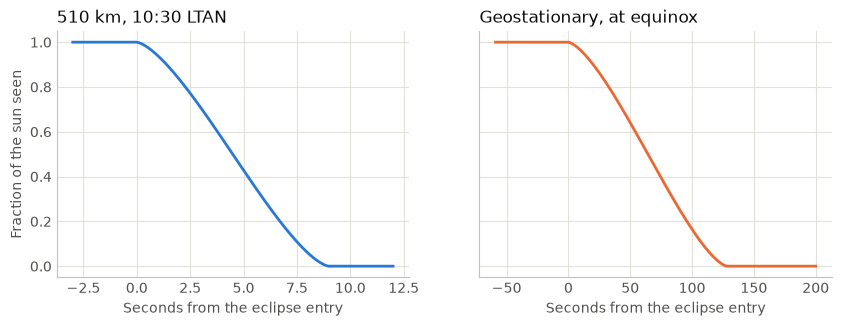

In [19]:
def light_through_entry(times, state, entry) -> tuple[np.ndarray, np.ndarray]:
    """Seconds from the eclipse entry, and the fraction of the sun seen."""
    seconds = np.asarray((times - entry).to_value(u.s))
    return seconds, light_fraction(state, sun_positions(times))


leo_times = entry + np.linspace(-3, 12, 301) * u.s
leo = light_through_entry(
    leo_times, run.orbit.states(leo_times, with_velocity=False), entry
)
geo_entry = geo_times[np.flatnonzero(geo_eclipse)[0]]
geo = light_through_entry(geo_times, geo_state, geo_entry)
window = (geo[0] > -60) & (geo[0] < 200)

figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
left.plot(*leo, color="#2a78d6", linewidth=2)
right.plot(geo[0][window], geo[1][window], color="#eb6834", linewidth=2)
left.set(title="510 km, 10:30 LTAN", xlabel="Seconds from the eclipse entry", ylabel="Fraction of the sun seen")
right.set(title="Geostationary, at equinox", xlabel="Seconds from the eclipse entry")
plt.show()

The constraint check is strict. An activity passes only if it spends no more than 1 s outside the illumination it expects. The 1 s, `CONSTRAINT_TOLERANCE`, covers numerical effects only: event times sit on the 1 ms grid, so such effects are a few milliseconds. A longer miss fails, with no warning step in between. The `outside [s]` column gives the time outside, however small.

## The statuses

Each occurrence gets a status. It is `ok`, or it names one or more problems:

| Status | What it means |
| --- | --- |
| `negative duration` | A fault of the trigger. A negative offset takes the end back to the start, or before it. The duration column shows by how much. The activity takes no time, and the next one starts where it started. |
| `outside constraint` | A fault of the constraint. The activity spends some time outside the illumination it expects. The `outside [s]` column gives that time. |
| `event never came` | The event never happens in the run, such as a crossing of a latitude the orbit never reaches. The activity runs to the end of the run. |
| `cut at end` | The activity would run past the end of the run, and is cut there. That is the normal end of the last activity. |

The run stops with an error only if a whole repeat of the list makes no progress, because every activity has a negative duration.

The list below makes each problem happen. The first activity ends a minute before the eclipse, so the eclipse activity starts in sunlight. The third ends 100 min before the next eclipse, which is before it starts. The last waits for a latitude of 85°, which this orbit never reaches.

In [20]:
problems = run_variant(
    [
        ["eclipse entry - 1 min", "sun pointing", "idle", "sunlit"],
        ["eclipse exit", "nadir", "idle", "eclipse"],
        ["eclipse entry - 100 min", "nadir", "idle"],
        ["30 min", "sun pointing", "idle", "sunlit"],
        ["latitude 85 deg", "nadir", "idle"],
    ],
    duration="2 orbits",
)
show_table(problems)

Occurrences: 5 in 1 repeat. Negative duration: 1. Outside constraint: 1. Event never came: 1. Cut at end: 0. Slew starts early: 0.


repeat,activity,start [UTC],end [UTC],duration [min],trigger,attitude,slew [s],mode,constraint,outside [s],status
1,1,2026-10-01T00:00:00.000,2026-10-01T00:27:21.369,27.36,eclipse entry - 1 min,sun pointing,,idle,sunlit,0.0,ok
1,2,2026-10-01T00:27:21.369,2026-10-01T01:03:15.398,35.90,eclipse exit,nadir,,idle,eclipse,60.0,outside constraint
1,3,2026-10-01T01:03:15.398,2026-10-01T00:23:12.086,-40.06,eclipse entry - 100 min,nadir,,idle,,,negative duration
1,4,2026-10-01T01:03:15.398,2026-10-01T01:33:15.398,30.00,30 min,sun pointing,,idle,sunlit,0.0,ok
1,5,2026-10-01T01:33:15.398,2026-10-01T03:09:42.297,96.45,latitude 85 deg,nadir,,idle,,,event never came


The Gantt chart marks the faults. A red box marks an occurrence outside its constraint. A dashed red line with a triangle marks a negative duration, at its start. The line runs past the box, because the next activity starts at the same time.

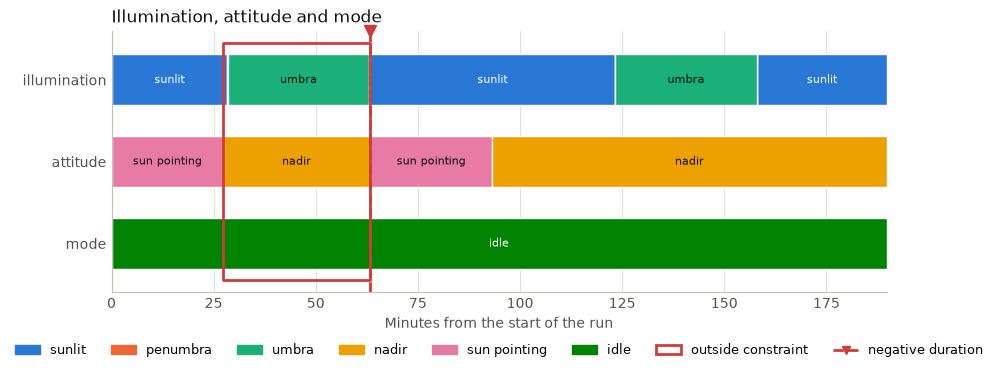

In [21]:
gantt_chart(problems)
plt.show()

## How the events are found

Every interval is closed at its start and open at its end. Every bound is rounded to a 1 ms grid, counted from J2000, so two bounds for the same instant compare equal. portion does the interval arithmetic.

An event is the start of an interval:

- an eclipse entry starts an eclipse, and an eclipse exit starts a sunlit piece;
- an umbra entry starts the umbra, and an umbra exit starts the time outside it;
- a northward crossing of a latitude starts the time above it, and a southward crossing starts the time below it.

A piece cut by the start or the end of the run is never taken for an event.

The shadow and the latitude are evaluated at each step. Where one changes between two steps, its edge is located by bisection, to 1 ms. Each midpoint evaluates the orbit again, so the result does not depend on the step. A shadow shorter than a step can be missed. So can a pair of crossings close to the orbit's highest latitude.

Over a day of the reference orbit, `ascending node` ends an activity once per nodal period, to the millisecond:

In [22]:
day = run_variant([["ascending node", "nadir", "idle"]], duration="1 day")

nodes = [occurrence.end for occurrence in day.occurrences if not occurrence.cut_at_end]
gaps = np.diff([(node - day.times[0]).to_value(u.s) for node in nodes])
print(f"ascending nodes   {len(nodes)}")
print(f"time between      {gaps.min():.3f} s to {gaps.max():.3f} s")
print(f"nodal period      {day.orbit.period.to(u.s):.3f}")

ascending nodes   16
time between      5691.148 s to 5691.150 s
nodal period      5691.149 s


## What a run gives

`run_scenario` returns a `ScenarioRun`. It holds the orbit on the grid, the eclipses with their umbra and penumbra, the light at each step, the three rows of the Gantt chart, every occurrence, and every slew. The scenario's functions draw on it:

- `run.activity_table` has one row per occurrence: the repeat, the activity, the start and end in UTC, the duration, the trigger, the attitude, the time of the slew into it, the mode, the constraint, the time outside it, and the status.
- `run.orbit` is where the states came from: the element set, or the trajectory.
- `run.slews` holds each slew: when its turn starts and ends, when settling ends, the angle, and the attitude it turns into.
- `run.articulations` gives the angle of each articulation of the 3D model at each step.
- `gantt_chart(run)` draws the illumination, the attitude and the mode against time.
- `ground_track_map(run, row, title)` draws the ground track over the coastlines, coloured by one row.
- `write_scenario_viewer(run, folder)` writes the viewer: the page, `scenario_viewer.html`, and its data, `scenario.js`.

### The viewer's data

The viewer is a web page that opens from a file on disk, with no Python and no server. Such a page cannot read a JSON file, but it can load a script. So `scenario.js` is JSON with one assignment in front, `window.quicksat.scenario = {...};`.

- Units are in the field names: `_s`, `_km`, `_km_s` and `_deg`.
- Every vector is in GCRS, and every time is in seconds from `start`.
- `q_body` turns body vectors into GCRS, and `q_earth` turns ITRS vectors into GCRS. Both are quaternions, `[x, y, z, w]`.
- Each slew is a piece of the attitude track with the value `slew` and a `target`, and each occurrence gives its slew time as `slew_s`.
- `light` is the fraction of the sun seen at each step, and the illumination track holds `sunlit`, `penumbra` and `umbra`. Both came with version 2 of the format.
- `model` holds the spacecraft's 3D model: its file name, and its bytes in base64. It is `null` without a model. It came with version 3.
- `orbit` gives the TLE lines, or the trajectory file with its format and frame, its samples and segments, who wrote it, its span and how its period was found. That came with version 4, which also renamed `nodal_period_s` to `period_s`.
- `model.articulations` gives each articulation's name, its part and that node's index in the glTF, its axis, the modes it parks in, and its angle at each step, as `angle_deg`. It came with version 5.
- The file holds no time stamps. The same inputs and the same code write the same bytes, and so the same `id`.

In [23]:
data = scenario_data(run)
grid = data["grid"]
steps = len(grid["t_s"])

print(f"format   {data['format']}, version {data['version']}, id {data['id']}")
print(f"grid     {steps} steps:")
for name, values in grid.items():
    print(f"           {name:9} {len(values) // steps} per step")
print("tracks   " + ", ".join(f"{name} {len(pieces)}" for name, pieces in data["tracks"].items()))
print(f"activity table  {len(data['occurrences'])} occurrences")
print(f"model    {data['model']['name']}, {len(data['model']['glb_base64']) * 3 / 4 / 1024:.1f} kB")
for joint in data["model"]["articulations"]:
    print(f"           {joint['name']}: node {joint['node']}, {len(joint['angle_deg'])} angles")

format   quicksat-scenario, version 5, id be484a39885aae87
grid     1709 steps:
           t_s       1 per step
           r_km      3 per step
           v_km_s    3 per step
           sun       3 per step
           lat_deg   1 per step
           lon_deg   1 per step
           beta_deg  1 per step
           light     1 per step
           q_body    4 per step
           q_earth   4 per step
tracks   illumination 13, attitude 11, mode 7
activity table  13 occurrences
model    spacecraft.glb, 17.8 kB
           wing +y: node 7, 1709 angles
           wing -y: node 12, 1709 angles


## The spacecraft's 3D model

`3d_model` names a GLB file, the binary form of glTF 2.0. The viewer draws it as the spacecraft. Without it, the viewer draws a 1 m cube. A relative path is taken from the folder of the scenario file. `3d_model` is either the file name alone, or a mapping with the `file` and its `articulations`, the parts that turn. The next section covers those.

- **Body axes and metres.** The model's x, y and z are the body's, and its unit is the metre. Its origin is the point the body turns about. glTF puts +y up by convention, but quicksat takes the axes as they are. So a model built with +z as nadir must keep it: in Blender, untick "+Y Up" when exporting.
- **Checked on load.** The file must be a GLB file of glTF 2.0. Draco and meshopt compression, and Basis Universal textures, are refused, because the page has no decoder for them.
- **Carried in `scenario.js`.** A page opened from disk cannot read the `.glb` file next to it. So `scenario.js` carries the file's bytes in base64, which is a third larger than the file.
- **Fitted to the view.** The page scales the model so that its farthest point from the origin sits at the same distance in every view. A model of any size then fits, but the views do not show its true size.
- **A picture, and the parts that turn.** Nothing reads the solar panels from the model yet. Only the articulations use its node names.

**Where to find models.** NASA publishes 3D models of many of its spacecraft:

- [NASA 3D Resources](https://science.nasa.gov/3d-resources/), the gallery;
- [the 3D models](https://github.com/nasa/NASA-3D-Resources/tree/master/3D%20Models) in NASA's GitHub repository;
- [the images and textures](https://github.com/nasa/NASA-3D-Resources/tree/master/Images%20and%20Textures) in the same repository.

A model in another format must be converted to GLB first. Its axes and units are its own, so turn and scale it into body axes and metres too, for example in Blender. Check the terms of use of each model.

This notebook's model has a node for each piece of the satellite. Each wing is one node, with its panels and their cells as children:

In [24]:
model = run.scenario.spacecraft_model
assert model is not None  # the reference scenario names one
gltf = read_glb_json(model.file)
print(f"{model.file.name}, {len(gltf['nodes'])} nodes:")


def show(index, depth=1):
    """A node's name, and its children's below it, indented."""
    node = gltf["nodes"][index]
    origin = f"  origin {node['translation']}" if "translation" in node else ""
    print("  " * depth + node["name"] + origin)
    for child in node.get("children", []):
        show(child, depth + 1)


for root in gltf["scenes"][0]["nodes"]:
    show(root)

spacecraft.glb, 17 nodes:
  Bus
  Front face
  Deck housing
  Aperture
  Spider
  Spider
  Secondary mirror
  Wing +y  origin [0.0, 0.24, -0.2675]
    Wing +y inner
    Wing +y inner cells
    Wing +y outer
    Wing +y outer cells
  Wing -y  origin [0.0, -0.24, -0.2675]
    Wing -y inner
    Wing -y inner cells
    Wing -y outer
    Wing -y outer cells


### Articulations

An articulation is a part of the model that turns about one body axis to face the sun, such as a solar wing. The scenario file lists them under `3d_model`, because each model names its parts its own way. This notebook's file turns both wings:

```yaml
3d_model:
  file: spacecraft.glb
  articulations:
    wing +y: {part: Wing +y, axis: +y, sun_axis: -z, park: {imaging: 0 deg}}
    wing -y: {part: Wing -y, axis: +y, sun_axis: -z, park: {imaging: 0 deg}}
```

| Key | What it holds |
| --- | --- |
| `part` | The name of the node that turns. It turns about the axis through its own origin, and its children turn with it. |
| `axis` | The drive axis, a body axis such as `+y` |
| `sun_axis` | The part's axis to turn to the sun, as the model draws the part. It must use a different body axis from `axis`. |
| `range` | Optional: the lowest and the highest angle, such as `[-90 deg, 90 deg]`, within -180 to 180 deg. All the way round by default. |
| `park` | Optional: a fixed angle for each mode named, such as `{imaging: 0 deg}`, inside the range |

**The angle at each step.** The angle is zero where the model draws the part, and turns right-handed about the axis.

- In a mode that `park` names, the part holds the park angle.
- Otherwise, it tracks the sun. The sun's direction in body axes loses its part along the drive axis, and the sun axis turns onto what is left. While the part tracks inside its range, its sun axis then meets the sun at the cosine $\sqrt{1 - (\hat{s} \cdot \hat{a})^2}$, the best that one axis allows.
- Where the sun asks for an angle outside the range, the part stops at the nearer end.
- The angle is set at each step from the geometry, with no drive and no rate limit. It follows the body through its slews.
- In eclipse, the part keeps tracking the sun behind the Earth, so it faces the sun when the sun rises.
- Where the sun lies along the drive axis, the tracking angle is undefined. The part then keeps the last angle it had.

**Checked on load.** The axis and the sun axis use different body axes. The range rises, and each park angle is inside it. Each mode in `park` must be one that an activity has, so a misspelt mode stops the load. Each `part` must name exactly one node in the model's scene.

**The model.** Each part that turns must be one node, with its origin on the drive axis. In this notebook's model, the wing nodes' origins sit at the wing roots, at the middle of the panels' thickness. A model that lists its parts flat has to group each wing under one node first, for example in Blender.

**In the viewer.** `scenario.js` carries each articulation's angles. The page turns the node about the axis in both 3D views, and shows each angle in the current data, with `parked` in a parking mode.

`run.articulations` gives the angles. In nadir, the wings turn with the orbit to follow the sun. In sun pointing, the cells already face the sun, so the angle stays at zero. In imaging, the wings park at zero. This scenario has no slews, so the angle jumps where the attitude changes. The plot breaks its line where the angle passes 180 deg, because +180 and -180 deg are the same angle:

nadir         angle from  -180.0 to  180.0 deg
sun pointing  angle from     0.0 to    0.0 deg
imaging       angle from     0.0 to    0.0 deg


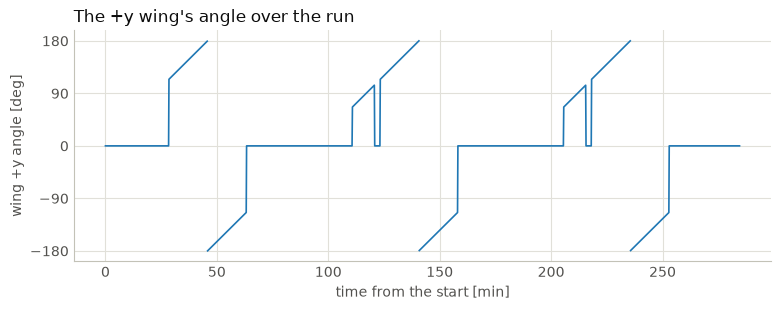

In [25]:
angles = np.asarray(run.articulations["wing +y"].to_value(u.deg))
modes = labels_at(run.mode, run.times)
attitudes = labels_at(run.attitude, run.times)
minutes = (run.times - run.times[0]).to_value(u.min)

for attitude in ("nadir", "sun pointing"):
    rows = (attitudes == attitude) & (modes != "imaging")
    low, high = np.round([angles[rows].min(), angles[rows].max()], 1) + 0.0
    print(f"{attitude:13} angle from {low:7.1f} to {high:6.1f} deg")
rows = modes == "imaging"
low, high = np.round([angles[rows].min(), angles[rows].max()], 1) + 0.0
print(f"{'imaging':13} angle from {low:7.1f} to {high:6.1f} deg")

# break the line where the angle wraps from +180 to -180 deg
wraps = np.flatnonzero(np.abs(np.diff(angles)) > 180) + 1
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.insert(minutes, wraps, np.nan), np.insert(angles, wraps, np.nan), lw=1.2)
ax.set_xlabel("time from the start [min]")
ax.set_ylabel("wing +y angle [deg]")
ax.set_yticks(range(-180, 181, 90))
ax.set_title("The +y wing's angle over the run")
plt.show()

## Limitations

What the scenario does not do, yet or at all:

- **The shadow's limits.** It has no atmosphere, which bends and dims the light near the edges, and no Moon. Its cones hold up to the tip of the umbra cone, 1.38 million km behind the Earth. Beyond it, the satellite counts as in penumbra, and the light is the ring of sun around the Earth.
- **Orbits from SGP4 or a file.** The orbit comes from a TLE or OMM file, an SSO definition, or a trajectory file: ECSV, or a CCSDS OEM in KVN. An XML OEM is not read. A manoeuvre inside one segment is smoothed over, so an OEM should start a new segment at each one.
- **Two attitudes, with fixed names.** There are no user-named attitudes yet. A slew uses one rate and one acceleration for every axis, unlike the agility budget, which has its own for roll and pitch.
- **Articulations turn at once.** A part takes its angle at each step, with no drive and no rate limit. It turns about one axis only, and only toward the sun. Nothing reads its panels yet: power will.
- **A strict constraint check.** Beyond the 1 s allowed for numerical effects, a miss of two seconds fails as a miss of an hour does. There is no warning margin.
- **Short runs.** A run covers an orbit to a day or two, so beta hardly changes in it. Seasons need a scenario each, such as winter and summer.
- **Events between steps.** A shadow shorter than one step, or two latitude crossings within one step, can be missed.